In [1]:
import os
import sys
import glob

import numpy                as     np

from   PIL                  import Image
from   tqdm                 import tqdm

In [ ]:
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from   src.analyses         import coverage_analysis
from   src.compute_features import compute_patch_appearance_features
from   src.routines         import flatten_features
from   src.feature_io       import save_features, load_features

In [3]:
features_to_compute                   = {
                                         'mean_intensity': True,
                                         'glcm'          : False,
                                         'rgb'           : True 
                                        }

In [4]:
real_images_dir                       = input("Path to real images")                   or '../data/real_images'
synth_images_dir                      = input("Path to synth images")                  or '../data/kde_synth_images'
features_dir                          = input("Path for saving or loading features")   or '../data/features'

In [5]:
real_features_file_name               = input("Enter filename for real features")      or 'test_real.npz'
synth_features_file_name              = input("Enter filename for synthetic features") or 'test_synth.npz'

In [6]:
real_patch_appearance_npz_file_path   = os.path.join(features_dir, real_features_file_name)
synth_patch_appearance_npz_file_path  = os.path.join(features_dir, synth_features_file_name)   

real_image_features                   = []
synthetic_image_features              = []

real_image_files                      = glob.glob(os.path.join(real_images_dir,  '*.png'))
synthetic_image_files                 = glob.glob(os.path.join(synth_images_dir, '*.png'))

In [7]:
if os.path.exists(real_patch_appearance_npz_file_path):
    all_real_image_appearance = load_features(real_patch_appearance_npz_file_path)

else:
    print("Processing real patches")
    for img_file in tqdm(real_image_files):
        img   = np.array(Image.open(img_file))
        feats = compute_patch_appearance_features(img, features_to_compute)

        real_image_features.append(feats)

    all_real_image_appearance  = flatten_features(real_image_features)

    save_features(all_real_image_appearance, real_patch_appearance_npz_file_path)

if os.path.exists(synth_patch_appearance_npz_file_path):
    all_synth_image_appearance = load_features(synth_patch_appearance_npz_file_path)

else:
    print("Processing synth patches")
    for img_file in tqdm(synthetic_image_files):
        img   = np.array(Image.open(img_file))
        feats = compute_patch_appearance_features(img, features_to_compute)
        
        synthetic_image_features.append(feats)

    all_synth_image_appearance = flatten_features(synthetic_image_features)

    save_features(all_synth_image_appearance, synth_patch_appearance_npz_file_path)

Keeping 4 features (≥ 50% valid values)
  Variance              : 0.061600
  Entropy               : 1.383610
  Distance_to_Centroid  : 0.428914
  Convex_Hull_Volume    : 0.471956
  Variance              : 0.046641
  Entropy               : 1.385486
  Distance_to_Centroid  : 0.372469
  Convex_Hull_Volume    : 0.687284


/home/alexander.webber/programming/ScoreCard/src/visualization.py:272: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/home/alexander.webber/programming/ScoreCard/src/visualization.py:272: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/home/alexander.webber/programming/ScoreCard/src/visualization.py:272: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/home/alexander.webber/programming/ScoreCard/src/visualization.py:272: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` va

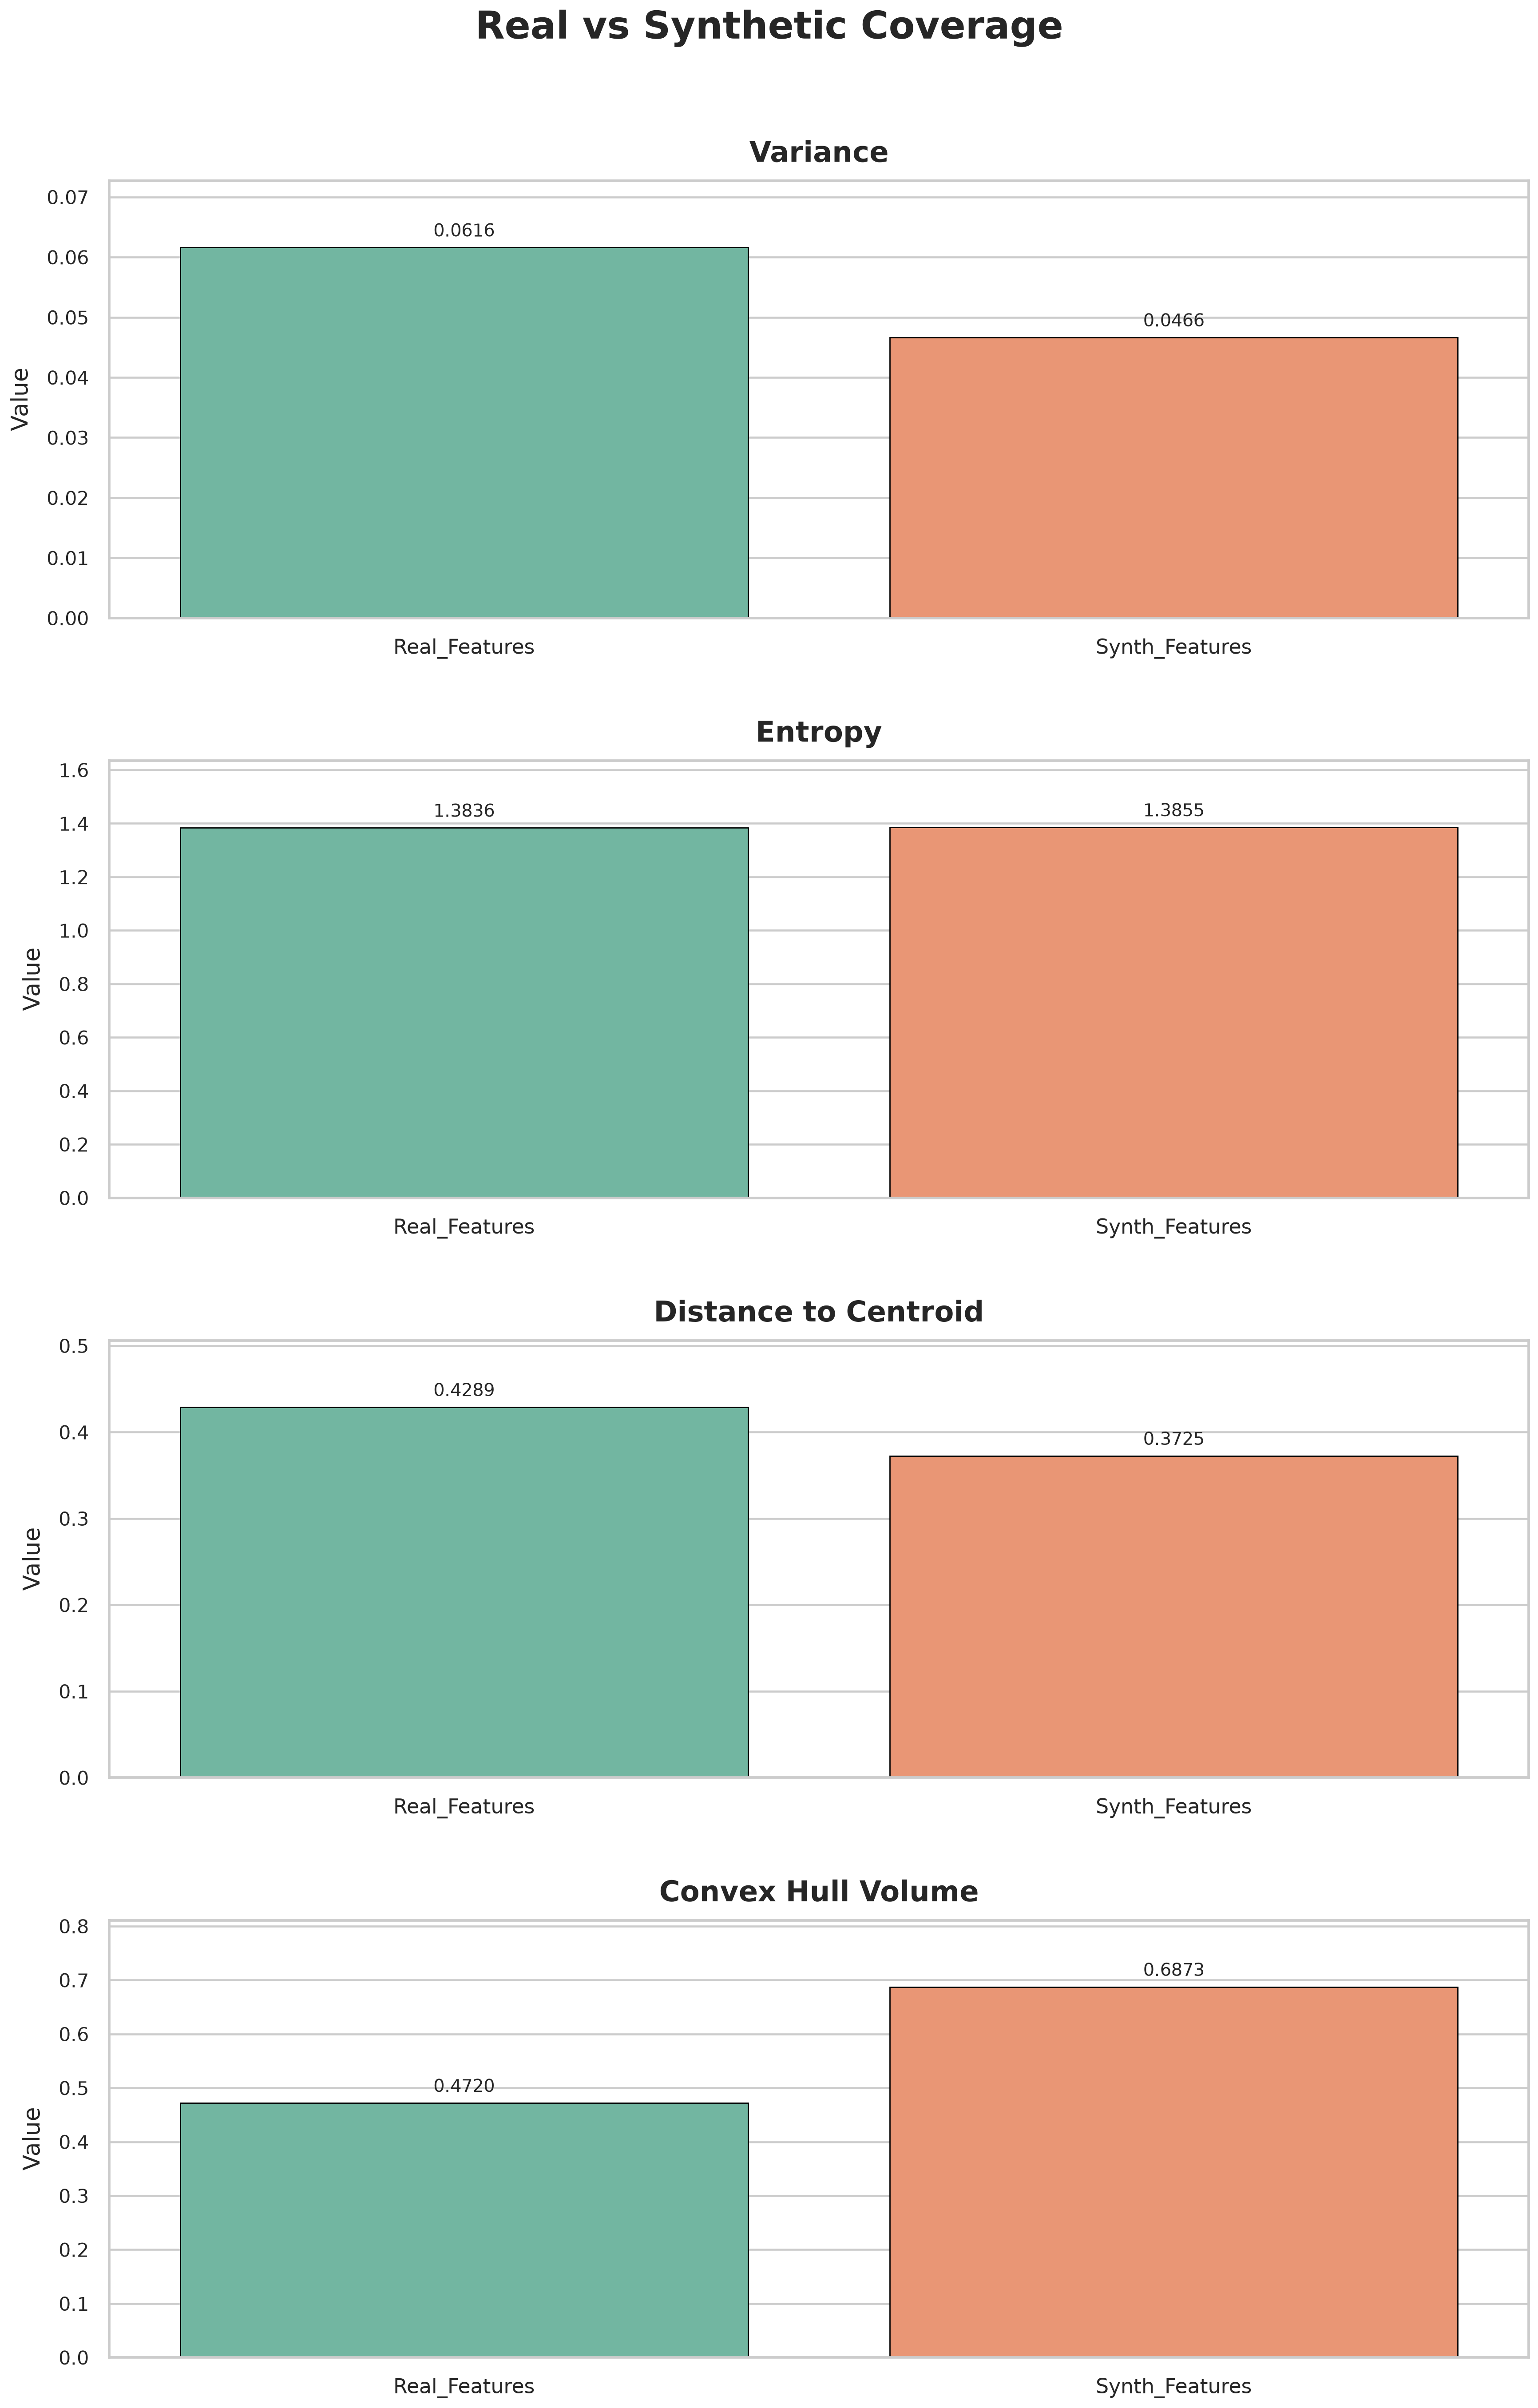

In [8]:
coverage_fig = coverage_analysis(features_dir, real_features_file_name, synth_features_file_name)
coverage_fig.show()